In [2]:
import requests
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

In [3]:
from google.colab import userdata
userdata.get('AQICN_TOKEN')

'fb00b1a694702af7d0b19fba3ead11458d1f717a'

**fetch raw data from an external API**

In [4]:
import requests

TOKEN = "fb00b1a694702af7d0b19fba3ead11458d1f717a"

city = "Karachi"

# API endpoint for AQI CN (waqi.info)
url = f"https://api.waqi.info/feed/{city}/?token={TOKEN}"

response = requests.get(url)
data = response.json()

print(data)

{'status': 'ok', 'data': {'aqi': 161, 'idx': 11790, 'attributions': [{'url': 'https://pk.usembassy.gov/', 'name': 'Pakistan Air Quality Monitor - US EPA', 'logo': 'US-StateDepartment.png'}, {'url': 'https://waqi.info/', 'name': 'World Air Quality Index Project'}], 'city': {'geo': [24.8415, 67.0091], 'name': 'Karachi US Consulate, Pakistan', 'url': 'https://aqicn.org/city/pakistan/karachi/us-consulate', 'location': ''}, 'dominentpol': 'pm25', 'iaqi': {'dew': {'v': -19}, 'h': {'v': 3}, 'p': {'v': 1016}, 'pm25': {'v': 161}, 't': {'v': 31}, 'w': {'v': 5.1}}, 'time': {'s': '2025-03-04 16:00:00', 'tz': '+05:00', 'v': 1741104000, 'iso': '2025-03-04T16:00:00+05:00'}, 'forecast': {'daily': {'o3': [{'avg': 15, 'day': '2025-03-02', 'max': 48, 'min': 6}, {'avg': 19, 'day': '2025-03-03', 'max': 23, 'min': 17}, {'avg': 13, 'day': '2025-03-04', 'max': 36, 'min': 4}, {'avg': 15, 'day': '2025-03-05', 'max': 52, 'min': 11}, {'avg': 15, 'day': '2025-03-06', 'max': 28, 'min': 5}, {'avg': 8, 'day': '2025-0

In [5]:
import pandas as pd

row = {
    "datetime": data["data"]["time"]["iso"],
    "city": data["data"]["city"]["name"],
    "aqi": data["data"]["aqi"],
    "pm25": data["data"]["iaqi"].get("pm25",{}).get("v"),
    "pm10": data["data"]["iaqi"].get("pm10",{}).get("v"),
    "co": data["data"]["iaqi"].get("co",{}).get("v"),
    "no2": data["data"]["iaqi"].get("no2",{}).get("v"),
    "so2": data["data"]["iaqi"].get("so2",{}).get("v"),
    "o3": data["data"]["iaqi"].get("o3",{}).get("v"),
    "temperature": data["data"]["iaqi"].get("t",{}).get("v"),
    "humidity": data["data"]["iaqi"].get("h",{}).get("v"),
    "pressure": data["data"]["iaqi"].get("p",{}).get("v"),
    "wind": data["data"]["iaqi"].get("w",{}).get("v"),
}

df = pd.DataFrame([row])
df

,datetime,city,aqi,pm25,pm10,co,no2,so2,o3,temperature,humidity,pressure,wind
0,2025-03-04T16:00:00+05:00,"Karachi US Consulate, Pakistan",161,161,None,None,None,None,None,31,3,1016,5.1


In [6]:
df = pd.DataFrame([row])

df["datetime"] = pd.to_datetime(df["datetime"])

df["hour"] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.day
df["month"] = df["datetime"].dt.month
df["weekday"] = df["datetime"].dt.dayofweek

df

,datetime,city,aqi,pm25,pm10,co,no2,so2,o3,temperature,humidity,pressure,wind,hour,day,month,weekday
0,2025-03-04 16:00:00+05:00,"Karachi US Consulate, Pakistan",161,161,None,None,None,None,None,31,3,1016,5.1,16,4,3,1


In [7]:
df["aqi_change_rate"] = df["aqi"].diff()
df

,datetime,city,aqi,pm25,pm10,co,no2,so2,o3,temperature,humidity,pressure,wind,hour,day,month,weekday,aqi_change_rate
0,2025-03-04 16:00:00+05:00,"Karachi US Consulate, Pakistan",161,161,None,None,None,None,None,31,3,1016,5.1,16,4,3,1,NaN


In [8]:
df["aqi_lag_1"] = df["aqi"].shift(1)
df

,datetime,city,aqi,pm25,pm10,co,no2,so2,o3,temperature,humidity,pressure,wind,hour,day,month,weekday,aqi_change_rate,aqi_lag_1
0,2025-03-04 16:00:00+05:00,"Karachi US Consulate, Pakistan",161,161,None,None,None,None,None,31,3,1016,5.1,16,4,3,1,NaN,NaN


In [9]:
df["aqi_lag_3"] = df["aqi"].shift(3)

In [10]:
df["aqi_lag_7"] = df["aqi"].shift(7)

In [11]:
df["target_aqi"] = df["aqi"].shift(-3)

In [12]:
df = df.sort_values("datetime").reset_index(drop=True)

In [13]:
df["datetime"].diff().value_counts().head(20)

,count
datetime,


In [14]:
df.isnull().sum()

,0
datetime,0
city,0
aqi,0
pm25,0
pm10,1
co,1
no2,1
so2,1
o3,1
temperature,0


***EDA***

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


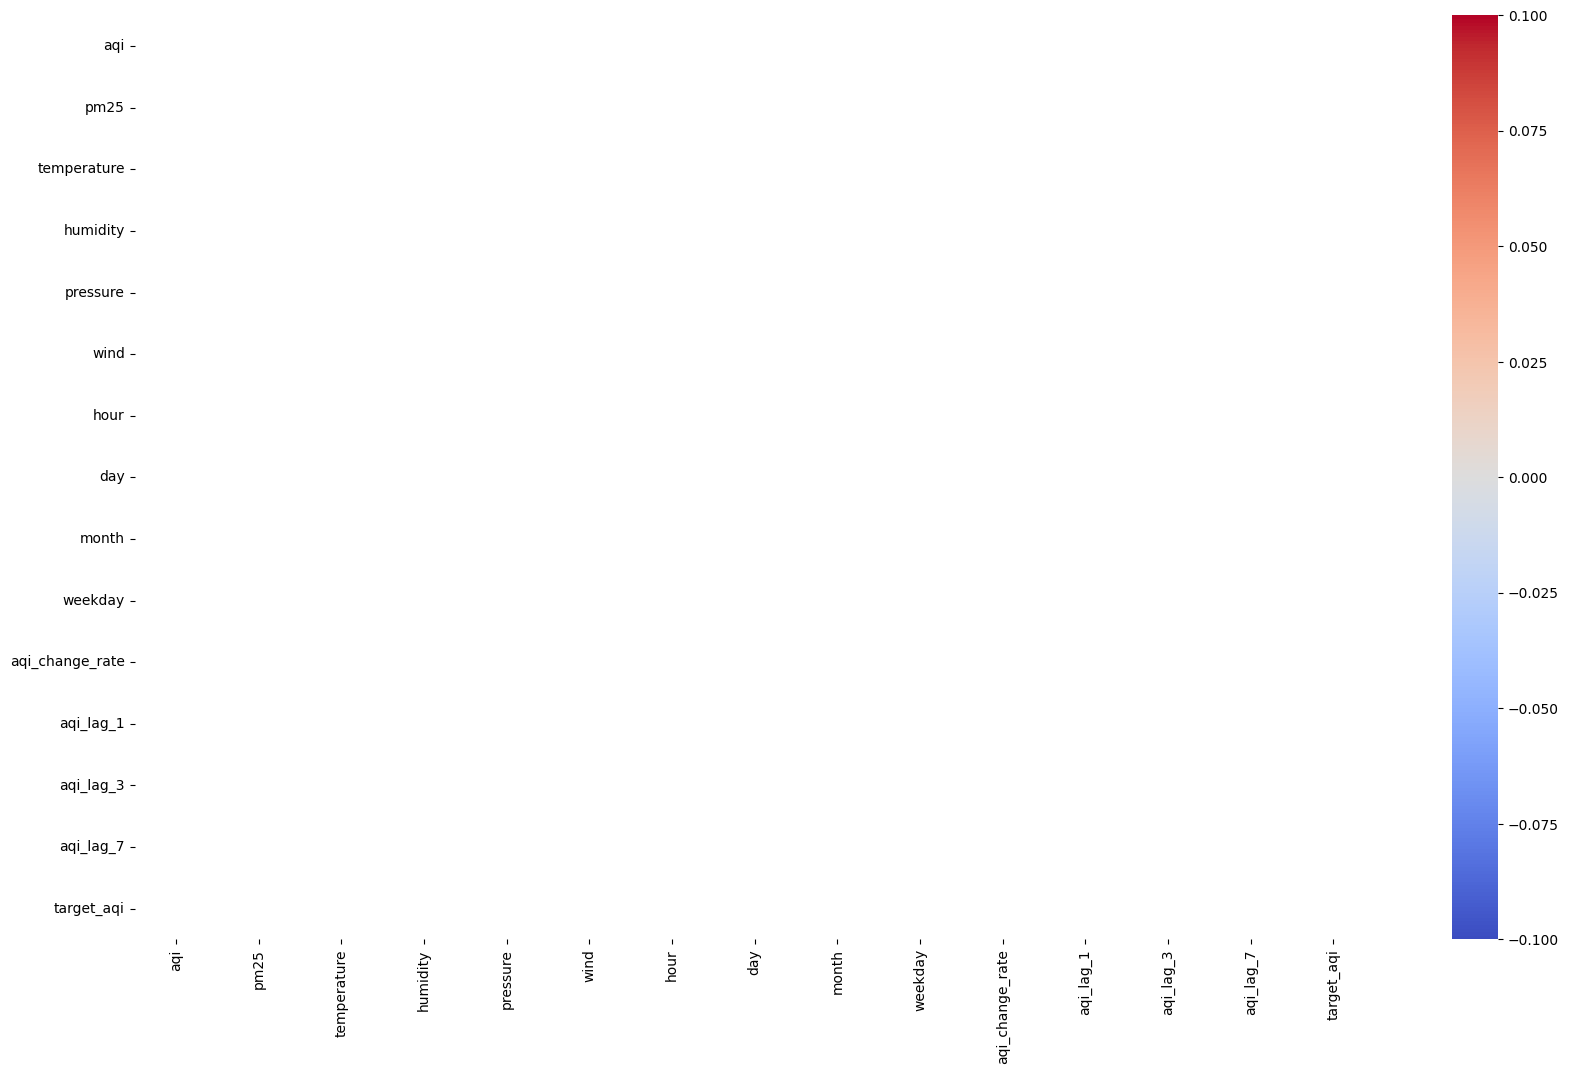

In [15]:
plt.figure(figsize=(20,12))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

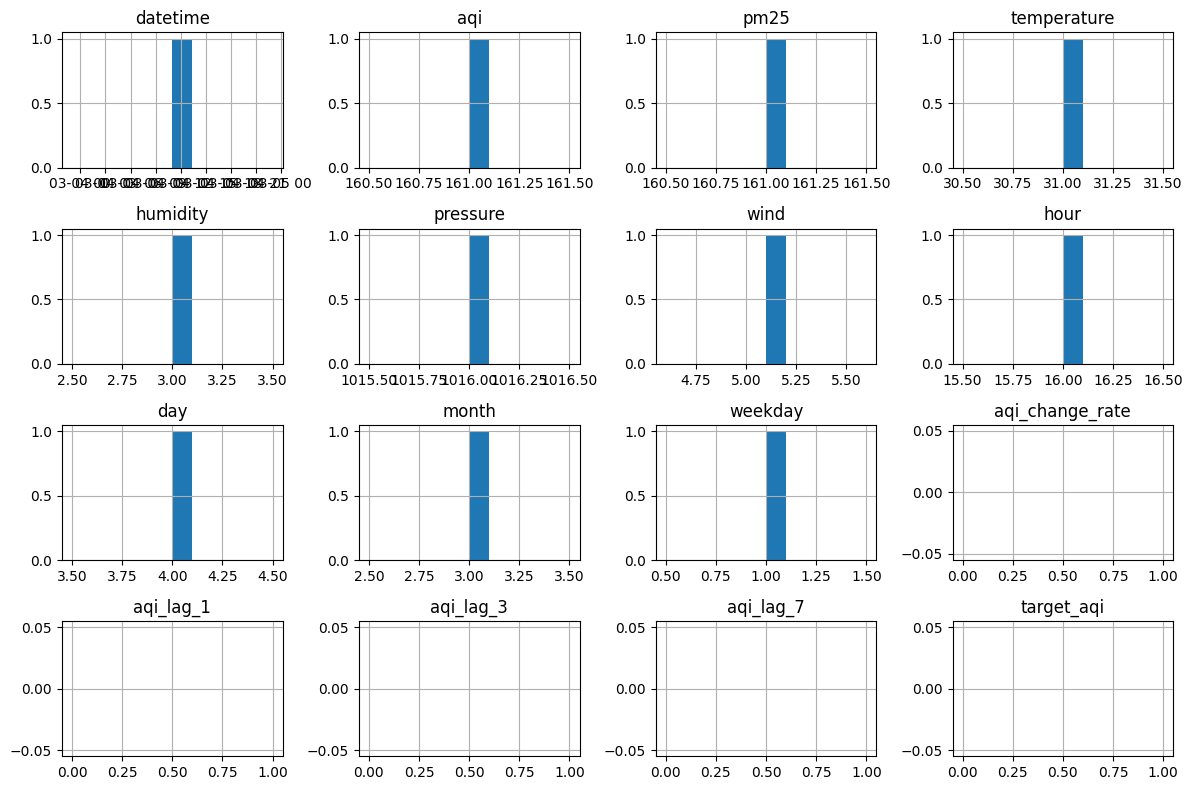

In [16]:
df.hist(figsize=(12,8))

plt.tight_layout()

plt.show()

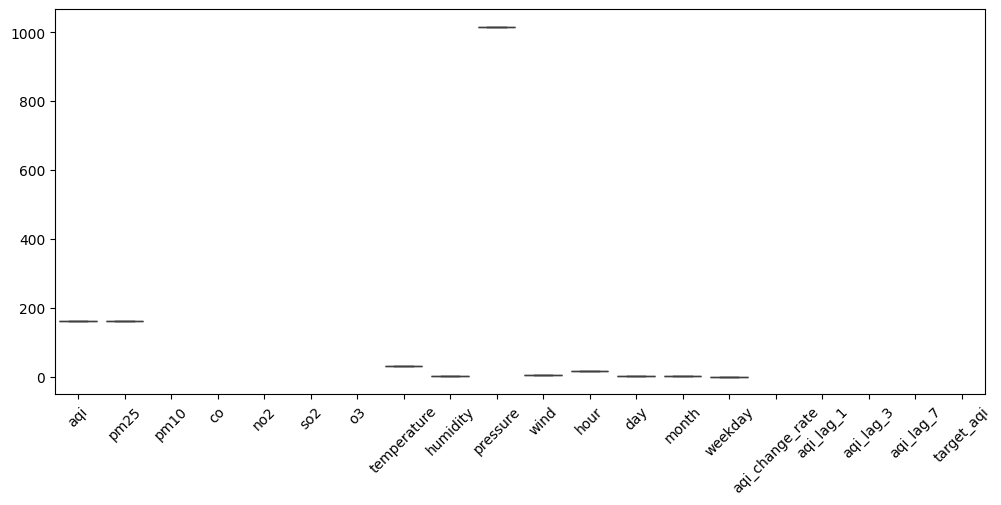

In [17]:
plt.figure(figsize=(12,5))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.show()

In [18]:
df.to_csv("aqi_data.csv")
df

,datetime,city,aqi,pm25,pm10,co,no2,so2,o3,temperature,...,wind,hour,day,month,weekday,aqi_change_rate,aqi_lag_1,aqi_lag_3,aqi_lag_7,target_aqi
0,2025-03-04 16:00:00+05:00,"Karachi US Consulate, Pakistan",161,161,None,None,None,None,None,31,...,5.1,16,4,3,1,NaN,NaN,NaN,NaN,NaN


**Historical Data**

In [19]:
import pandas as pd

df = pd.read_csv("/content/air_quality_historical.csv")

df.head()

,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
0,2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-08-04,60.378947,28.036842,495.210526,22.426316,24.389474,62.368421,0.806842,47.210526,2.100000,NaN,NaN
4,2022-08-05,58.337500,28.212500,507.416667,22.725000,24.879167,53.500000,0.794167,42.750000,1.527083,82.263158,63.0


In [20]:
df.shape

(1298, 12)

In [21]:
df.columns

Index(['date', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide',
       'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust', 'uv_index',
       'us_aqi', 'european_aqi'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1298 entries, 0 to 1297
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1298 non-null   object 
 1   pm10                   1295 non-null   float64
 2   pm2_5                  1295 non-null   float64
 3   carbon_monoxide        1295 non-null   float64
 4   nitrogen_dioxide       1295 non-null   float64
 5   sulphur_dioxide        1295 non-null   float64
 6   ozone                  1295 non-null   float64
 7   aerosol_optical_depth  1295 non-null   float64
 8   dust                   1295 non-null   float64
 9   uv_index               1295 non-null   float64
 10  us_aqi                 1294 non-null   float64
 11  european_aqi           1294 non-null   float64
dtypes: float64(11), object(1)
memory usage: 121.8+ KB


In [23]:
df = df.rename(columns={
    "us_aqi": "aqi",
    "pm2_5": "pm25",
    "carbon_monoxide": "co",
    "nitrogen_dioxide": "no2",
    "sulphur_dioxide": "so2",
    "ozone": "o3"
})

df.head()

,date,pm10,pm25,co,no2,so2,o3,aerosol_optical_depth,dust,uv_index,aqi,european_aqi
0,2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-08-04,60.378947,28.036842,495.210526,22.426316,24.389474,62.368421,0.806842,47.210526,2.100000,NaN,NaN
4,2022-08-05,58.337500,28.212500,507.416667,22.725000,24.879167,53.500000,0.794167,42.750000,1.527083,82.263158,63.0


**Feature Engineering**

In [24]:
import pandas as pd

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Time features
df["hour"] = df["date"].dt.hour
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["weekday"] = df["date"].dt.weekday

df.head()

,date,pm10,pm25,co,no2,so2,o3,aerosol_optical_depth,dust,uv_index,aqi,european_aqi,hour,day,month,weekday
0,2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,8,0
1,2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,8,1
2,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3,8,2
3,2022-08-04,60.378947,28.036842,495.210526,22.426316,24.389474,62.368421,0.806842,47.210526,2.100000,NaN,NaN,0,4,8,3
4,2022-08-05,58.337500,28.212500,507.416667,22.725000,24.879167,53.500000,0.794167,42.750000,1.527083,82.263158,63.0,0,5,8,4


In [25]:
df["aqi_change_rate"] = df["aqi"].diff()
df

,date,pm10,pm25,co,no2,so2,o3,aerosol_optical_depth,dust,uv_index,aqi,european_aqi,hour,day,month,weekday,aqi_change_rate
0,2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,8,0,NaN
1,2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,8,1,NaN
2,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3,8,2,NaN
3,2022-08-04,60.378947,28.036842,495.210526,22.426316,24.389474,62.368421,0.806842,47.210526,2.100000,NaN,NaN,0,4,8,3,NaN
4,2022-08-05,58.337500,28.212500,507.416667,22.725000,24.879167,53.500000,0.794167,42.750000,1.527083,82.263158,63.000000,0,5,8,4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1293,2026-02-14,32.591667,25.787500,739.291667,28.245833,18.820833,67.458333,0.156250,10.041667,1.481250,93.958333,65.958333,0,14,2,5,-32.375000
1294,2026-02-15,54.070833,33.258333,527.166667,26.354167,17.329167,61.458333,0.211250,34.125000,1.429167,87.375000,63.708333,0,15,2,6,-6.583333
1295,2026-02-16,52.175000,31.879167,458.208333,22.866667,14.079167,65.458333,0.278333,31.500000,1.354167,98.166667,67.791667,0,16,2,0,10.791667
1296,2026-02-17,51.783333,30.287500,865.541667,27.516667,20.270833,71.541667,0.448750,35.000000,1.264583,85.000000,62.958333,0,17,2,1,-13.166667


In [26]:
df["date"].min(), df["date"].max()

(Timestamp('2022-08-01 00:00:00'), Timestamp('2026-02-18 00:00:00'))

In [27]:
df = df.sort_values("date").reset_index(drop=True)

In [28]:
df["aqi_lag_1"] = df["aqi"].shift(1)

In [29]:
df["aqi_lag_7"] = df["aqi"].shift(7)

In [30]:
df["target_aqi"] = df["aqi"].shift(-3)
df

,date,pm10,pm25,co,no2,so2,o3,aerosol_optical_depth,dust,uv_index,aqi,european_aqi,hour,day,month,weekday,aqi_change_rate,aqi_lag_1,aqi_lag_7,target_aqi
0,2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,8,0,NaN,NaN,NaN,NaN
1,2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,8,1,NaN,NaN,NaN,82.263158
2,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3,8,2,NaN,NaN,NaN,83.833333
3,2022-08-04,60.378947,28.036842,495.210526,22.426316,24.389474,62.368421,0.806842,47.210526,2.100000,NaN,NaN,0,4,8,3,NaN,NaN,NaN,147.250000
4,2022-08-05,58.337500,28.212500,507.416667,22.725000,24.879167,53.500000,0.794167,42.750000,1.527083,82.263158,63.000000,0,5,8,4,NaN,NaN,NaN,176.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1293,2026-02-14,32.591667,25.787500,739.291667,28.245833,18.820833,67.458333,0.156250,10.041667,1.481250,93.958333,65.958333,0,14,2,5,-32.375000,126.333333,96.208333,85.000000
1294,2026-02-15,54.070833,33.258333,527.166667,26.354167,17.329167,61.458333,0.211250,34.125000,1.429167,87.375000,63.708333,0,15,2,6,-6.583333,93.958333,125.000000,91.458333
1295,2026-02-16,52.175000,31.879167,458.208333,22.866667,14.079167,65.458333,0.278333,31.500000,1.354167,98.166667,67.791667,0,16,2,0,10.791667,87.375000,108.583333,NaN
1296,2026-02-17,51.783333,30.287500,865.541667,27.516667,20.270833,71.541667,0.448750,35.000000,1.264583,85.000000,62.958333,0,17,2,1,-13.166667,98.166667,88.708333,NaN


In [31]:
df["date"].diff().value_counts().head(10)

,count
date,
1 days,1297


In [32]:
df["date"].diff().value_counts().head(20)

,count
date,
1 days,1297


In [33]:
df = df.dropna()

In [34]:
df.head()
df.shape

(1284, 20)

In [35]:
df.to_csv(
    "karachi_aqi_features.csv",
    index=False
)

**Load Historical Data**

In [36]:
df.head()

,date,pm10,pm25,co,no2,so2,o3,aerosol_optical_depth,dust,uv_index,aqi,european_aqi,hour,day,month,weekday,aqi_change_rate,aqi_lag_1,aqi_lag_7,target_aqi
11,2022-08-12,49.291667,31.216667,605.750000,34.491667,32.987500,82.208333,0.370000,13.583333,1.337500,138.375000,88.666667,0,12,8,4,-62.041667,200.416667,82.263158,79.541667
12,2022-08-13,48.941667,32.137500,704.000000,35.566667,49.345833,94.000000,0.260000,3.083333,1.954167,99.750000,66.125000,0,13,8,5,-38.625000,138.375000,83.833333,77.958333
13,2022-08-14,39.908333,24.970833,475.916667,20.325000,27.833333,99.500000,0.312917,3.375000,2.043750,105.083333,66.208333,0,14,8,6,5.333333,99.750000,147.250000,79.541667
14,2022-08-15,38.450000,25.370833,678.125000,47.379167,53.912500,58.875000,0.360417,2.958333,1.135417,79.541667,61.041667,0,15,8,0,-25.541667,105.083333,176.750000,66.708333
15,2022-08-16,43.645833,28.066667,644.250000,39.541667,38.458333,70.708333,0.421250,9.416667,1.156250,77.958333,58.708333,0,16,8,1,-1.583333,79.541667,152.500000,73.458333


In [37]:
df.columns

Index(['date', 'pm10', 'pm25', 'co', 'no2', 'so2', 'o3',
       'aerosol_optical_depth', 'dust', 'uv_index', 'aqi', 'european_aqi',
       'hour', 'day', 'month', 'weekday', 'aqi_change_rate', 'aqi_lag_1',
       'aqi_lag_7', 'target_aqi'],
      dtype='object')

In [38]:
df.isnull().sum()

,0
date,0
pm10,0
pm25,0
co,0
no2,0
so2,0
o3,0
aerosol_optical_depth,0
dust,0
uv_index,0


In [39]:
df["date"] = pd.to_datetime(df["date"])

print(df["date"].min())
print(df["date"].max())

2022-08-12 00:00:00
2026-02-15 00:00:00


/tmp/ipykernel_10696/1503487918.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["date"] = pd.to_datetime(df["date"])


In [40]:
import requests

start_date = df["date"].min().strftime("%Y-%m-%d")
end_date = df["date"].max().strftime("%Y-%m-%d")


url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=24.8607"
    "&longitude=67.0011"
    f"&start_date={start_date}"
    f"&end_date={end_date}"
    "&daily="
    "temperature_2m_mean,"
    "relative_humidity_2m_mean,"
    "wind_speed_10m_max,"
    "precipitation_sum"
    "&timezone=Asia/Karachi"
)


response = requests.get(url)

weather_data = response.json()

In [41]:
weather_df = pd.DataFrame({

    "date": weather_data["daily"]["time"],

    "temperature":
    weather_data["daily"]["temperature_2m_mean"],

    "humidity":
    weather_data["daily"]["relative_humidity_2m_mean"],

    "wind_speed":
    weather_data["daily"]["wind_speed_10m_max"],

    "rain":
    weather_data["daily"]["precipitation_sum"]

})


weather_df["date"] = pd.to_datetime(weather_df["date"])


weather_df.head()

,date,temperature,humidity,wind_speed,rain
0,2022-08-12,28.1,86,40.5,82.7
1,2022-08-13,27.2,87,20.6,21.2
2,2022-08-14,27.5,84,25.9,43.0
3,2022-08-15,27.7,87,21.6,32.0
4,2022-08-16,27.6,87,14.1,11.1


In [42]:
df.head()

,date,pm10,pm25,co,no2,so2,o3,aerosol_optical_depth,dust,uv_index,aqi,european_aqi,hour,day,month,weekday,aqi_change_rate,aqi_lag_1,aqi_lag_7,target_aqi
11,2022-08-12,49.291667,31.216667,605.750000,34.491667,32.987500,82.208333,0.370000,13.583333,1.337500,138.375000,88.666667,0,12,8,4,-62.041667,200.416667,82.263158,79.541667
12,2022-08-13,48.941667,32.137500,704.000000,35.566667,49.345833,94.000000,0.260000,3.083333,1.954167,99.750000,66.125000,0,13,8,5,-38.625000,138.375000,83.833333,77.958333
13,2022-08-14,39.908333,24.970833,475.916667,20.325000,27.833333,99.500000,0.312917,3.375000,2.043750,105.083333,66.208333,0,14,8,6,5.333333,99.750000,147.250000,79.541667
14,2022-08-15,38.450000,25.370833,678.125000,47.379167,53.912500,58.875000,0.360417,2.958333,1.135417,79.541667,61.041667,0,15,8,0,-25.541667,105.083333,176.750000,66.708333
15,2022-08-16,43.645833,28.066667,644.250000,39.541667,38.458333,70.708333,0.421250,9.416667,1.156250,77.958333,58.708333,0,16,8,1,-1.583333,79.541667,152.500000,73.458333


In [43]:
weather_df.head()

,date,temperature,humidity,wind_speed,rain
0,2022-08-12,28.1,86,40.5,82.7
1,2022-08-13,27.2,87,20.6,21.2
2,2022-08-14,27.5,84,25.9,43.0
3,2022-08-15,27.7,87,21.6,32.0
4,2022-08-16,27.6,87,14.1,11.1


**Merge AQCIN AND WEATHER**

In [44]:
merged_df = pd.merge(
    df,
    weather_df,
    on="date",
    how="inner"
)

In [45]:
merged_df.head()

,date,pm10,pm25,co,no2,so2,o3,aerosol_optical_depth,dust,uv_index,...,month,weekday,aqi_change_rate,aqi_lag_1,aqi_lag_7,target_aqi,temperature,humidity,wind_speed,rain
0,2022-08-12,49.291667,31.216667,605.750000,34.491667,32.987500,82.208333,0.370000,13.583333,1.337500,...,8,4,-62.041667,200.416667,82.263158,79.541667,28.1,86,40.5,82.7
1,2022-08-13,48.941667,32.137500,704.000000,35.566667,49.345833,94.000000,0.260000,3.083333,1.954167,...,8,5,-38.625000,138.375000,83.833333,77.958333,27.2,87,20.6,21.2
2,2022-08-14,39.908333,24.970833,475.916667,20.325000,27.833333,99.500000,0.312917,3.375000,2.043750,...,8,6,5.333333,99.750000,147.250000,79.541667,27.5,84,25.9,43.0
3,2022-08-15,38.450000,25.370833,678.125000,47.379167,53.912500,58.875000,0.360417,2.958333,1.135417,...,8,0,-25.541667,105.083333,176.750000,66.708333,27.7,87,21.6,32.0
4,2022-08-16,43.645833,28.066667,644.250000,39.541667,38.458333,70.708333,0.421250,9.416667,1.156250,...,8,1,-1.583333,79.541667,152.500000,73.458333,27.6,87,14.1,11.1


In [46]:
merged_df.isnull().sum()

,0
date,0
pm10,0
pm25,0
co,0
no2,0
so2,0
o3,0
aerosol_optical_depth,0
dust,0
uv_index,0


In [47]:
merged_df.to_csv(
    "karachi_aqi_final_features.csv",
    index=False
)

In [48]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1284 entries, 0 to 1283
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1284 non-null   datetime64[ns]
 1   pm10                   1284 non-null   float64       
 2   pm25                   1284 non-null   float64       
 3   co                     1284 non-null   float64       
 4   no2                    1284 non-null   float64       
 5   so2                    1284 non-null   float64       
 6   o3                     1284 non-null   float64       
 7   aerosol_optical_depth  1284 non-null   float64       
 8   dust                   1284 non-null   float64       
 9   uv_index               1284 non-null   float64       
 10  aqi                    1284 non-null   float64       
 11  european_aqi           1284 non-null   float64       
 12  hour                   1284 non-null   int32         
 13  day

In [49]:
!pip install hopsworks

In [50]:
import hopsworks

project = hopsworks.login(
    api_key_value="V6vjgGV7AW6AopgA.qlOlrMRATcXikjDjUMT6zYsiMV5ObPiNj9ktWDjidqkcX8PiQs97bXELklo2IRWX"
)
fs = project.get_feature_store()


Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/42159


**Create a Feature Group**

In [51]:
!pip install delta-spark

In [52]:
feature_group = fs.get_or_create_feature_group(
    name="karachi_aqi_features",
    version=1,
    description="Karachi AQI forecasting features with weather data",
    primary_key=["date"],
    event_time="date",
    time_travel_format="HUDI"
)

In [53]:
merged_df["date"].duplicated().sum()

np.int64(0)

In [54]:
!pip install confluent-kafka

In [55]:
feature_group.insert(merged_df)

Uploading Dataframe: 100.00% |██████████| Rows 1284/1284 | Elapsed Time: 00:01 | Remaining Time: 00:00


Launching job: karachi_aqi_features_1_offline_fg_materialization
Job started successfully, you can follow the progress at 
https://eu-west.cloud.hopsworks.ai:443/p/42159/jobs/named/karachi_aqi_features_1_offline_fg_materialization/executions


(Job('karachi_aqi_features_1_offline_fg_materialization', 'SPARK'), None)

**Trainning Pipeline**

In [56]:
df = merged_df.copy()

In [57]:
feature_group = fs.get_feature_group(
    name="karachi_aqi_features",
    version=1
)

training_df = feature_group.read()

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.64s) 


In [58]:
query = feature_group.select_all()

In [59]:
feature_view = fs.get_or_create_feature_view(
    name="aqi_training_view",
    version=1,
    description="AQI forecasting using feature store",
    query=query,
    labels=["aqi"]
)

print("Feature View Created")

Feature View Created


**Fetch Training Data from Feature View**

In [60]:
# Get Feature View

fv = fs.get_feature_view(
    name="aqi_training_view",
    version=1
)


# Fetch training dataset

X_train, y_train = fv.training_data(
    start_time="2022-08-12 ",
    end_time="2026-02-15"
)

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.40s) 


In [61]:
training_df.head()

,date,pm10,pm25,co,no2,so2,o3,aerosol_optical_depth,dust,uv_index,...,month,weekday,aqi_change_rate,aqi_lag_1,aqi_lag_7,target_aqi,temperature,humidity,wind_speed,rain
0,2024-08-03 00:00:00+00:00,116.329167,32.116667,231.958333,15.495833,5.520833,42.666667,1.384167,188.833333,0.491667,...,8,5,9.333333,77.500000,93.166667,76.625000,29.2,82,25.3,0.2
1,2026-01-27 00:00:00+00:00,23.958333,19.137500,745.041667,23.429167,25.483333,83.583333,0.140000,8.458333,1.254167,...,1,1,-2.583333,75.416667,102.458333,71.958333,17.8,40,12.6,0.0
2,2025-11-28 00:00:00+00:00,38.529167,37.541667,704.500000,16.441667,20.420833,111.291667,0.352917,1.625000,1.050000,...,11,4,-0.625000,98.583333,105.750000,96.833333,22.5,29,13.4,0.0
3,2025-08-23 00:00:00+00:00,50.766667,25.262500,254.250000,10.400000,9.512500,57.958333,0.706250,43.541667,1.433333,...,8,5,-6.833333,80.416667,83.666667,75.833333,28.2,85,21.1,1.6
4,2024-04-06 00:00:00+00:00,49.000000,15.304167,263.458333,12.020833,5.762500,119.208333,0.327083,57.666667,2.025000,...,4,5,7.375000,66.666667,80.041667,61.666667,26.7,60,27.3,0.0


In [62]:
training_df = training_df.dropna()

In [63]:
training_df.columns

Index(['date', 'pm10', 'pm25', 'co', 'no2', 'so2', 'o3',
       'aerosol_optical_depth', 'dust', 'uv_index', 'aqi', 'european_aqi',
       'hour', 'day', 'month', 'weekday', 'aqi_change_rate', 'aqi_lag_1',
       'aqi_lag_7', 'target_aqi', 'temperature', 'humidity', 'wind_speed',
       'rain'],
      dtype='object')

In [64]:
X = training_df.drop(
    columns=[
        "target_aqi",
        "date"
    ]
)

y = training_df["target_aqi"]

In [65]:
print(X.shape)
print(X.columns.tolist())

(1284, 22)
['pm10', 'pm25', 'co', 'no2', 'so2', 'o3', 'aerosol_optical_depth', 'dust', 'uv_index', 'aqi', 'european_aqi', 'hour', 'day', 'month', 'weekday', 'aqi_change_rate', 'aqi_lag_1', 'aqi_lag_7', 'temperature', 'humidity', 'wind_speed', 'rain']


**Split training and testing data**

In [72]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1027, 22)
X_test: (257, 22)
y_train: (1027,)
y_test: (257,)


In [68]:
print(X_train.shape)
print(X_test.shape)

(1026, 23)
(257, 23)


In [71]:
print(X.columns.tolist())
print(X.shape)
print(X.dtypes)

['pm10', 'pm25', 'co', 'no2', 'so2', 'o3', 'aerosol_optical_depth', 'dust', 'uv_index', 'aqi', 'european_aqi', 'hour', 'day', 'month', 'weekday', 'aqi_change_rate', 'aqi_lag_1', 'aqi_lag_7', 'temperature', 'humidity', 'wind_speed', 'rain']
(1284, 22)
pm10                     float64
pm25                     float64
co                       float64
no2                      float64
so2                      float64
o3                       float64
aerosol_optical_depth    float64
dust                     float64
uv_index                 float64
aqi                      float64
european_aqi             float64
hour                       int32
day                        int32
month                      int32
weekday                    int32
aqi_change_rate          float64
aqi_lag_1                float64
aqi_lag_7                float64
temperature              float64
humidity                   int64
wind_speed               float64
rain                     float64
dtype: object


**Models**

**BaseLine**

In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_scaled,
    y_train
)

ridge_predictions = ridge_model.predict(X_test_scaled)

print("Ridge trained successfully.")

Ridge trained successfully.


In [74]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(model_name, model, X_test, y_test):

    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))
    mae = mean_absolute_error(y_test, ridge_predictions)
    r2 = r2_score(y_test, ridge_predictions)

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }


print("RMSE:",
      np.sqrt(mean_squared_error(y_test, ridge_predictions)))

print("MAE:",
      mean_absolute_error(y_test, ridge_predictions))

print("R2:",
      r2_score(y_test, ridge_predictions))

RMSE: 24.260074144691337
MAE: 17.755629513205633
R2: 0.33566435743453027


**RandomForest**

In [75]:
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)


rf_model.fit(
    X_train,
    y_train
)

print("Model trained")

Model trained


In [76]:
rf_pred = rf_model.predict(X_test)

**Evaluate Random Forest**

In [77]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(model_name, model, X_test, y_test):

    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
    mae = mean_absolute_error(y_test, rf_pred)
    r2 = r2_score(y_test, rf_pred)

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }


print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("R2:",
      r2_score(y_test, rf_pred))

RMSE: 24.177870967224873
MAE: 17.299551718547345
R2: 0.3401588184903733


**XGBoost**

In [78]:
!pip install xgboost

In [79]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [80]:
xgb_predictions = xgb_model.predict(X_test)


In [81]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(model_name, model, X_test, y_test):

    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
    mae = mean_absolute_error(y_test, xgb_predictions)
    r2 = r2_score(y_test, xgb_predictions)

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }


print("RMSE:",
      np.sqrt(mean_squared_error(y_test, xgb_predictions)))

print("MAE:",
      mean_absolute_error(y_test, xgb_predictions))

print("R2:",
      r2_score(y_test, xgb_predictions))

RMSE: 25.051502054816652
MAE: 17.476195348994434
R2: 0.29161256823703574


**Advanced Model**

***LSTM***

In [82]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.9
    Uninstalling protobuf-4.25.9:
      Successfully uninstalled protobuf-4.25.9
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hopsworks 5.0.4 requires protobuf<5.0.0,>=4.25.4, but you have protobuf 7.35.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.1 which is incompatible.


In [83]:
print(X_train.shape)

(1027, 22)


In [84]:
import numpy as np

def create_sequences(X, y, window=24):

    X_seq = []
    y_seq = []

    for i in range(len(X)-window):

        X_seq.append(
            X[i:i+window]
        )

        y_seq.append(
            y[i+window]
        )

    return np.array(X_seq), np.array(y_seq)

In [85]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [86]:
X_train_lstm, y_train_lstm = create_sequences(
    X_train_scaled,
    y_train.values,
    window=24
)

X_test_lstm, y_test_lstm = create_sequences(
    X_test_scaled,
    y_test.values,
    window=24
)


print("X_train_lstm shape:", X_train_lstm.shape)
print("y_train_lstm shape:", y_train_lstm.shape)
print("X_test_lstm shape:", X_test_lstm.shape)
print("y_test_lstm shape:", y_test_lstm.shape)

X_train_lstm shape: (1003, 24, 22)
y_train_lstm shape: (1003,)
X_test_lstm shape: (233, 24, 22)
y_test_lstm shape: (233,)


In [87]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout


lstm_model = Sequential([

    LSTM(
        64,
        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )
    ),

    Dropout(0.2),

    Dense(32,activation="relu"),

    Dense(1)

])


lstm_model.compile(
    optimizer="adam",
    loss="mse"
)


lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,385 (95.25 KB)

 Trainable params: 24,385 (95.25 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - loss: 9100.3486 - val_loss: 7050.8838
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 7633.8154 - val_loss: 5546.6343
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 5969.6265 - val_loss: 3976.4189
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 4233.6714 - val_loss: 2512.4985
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 2806.8860 - val_loss: 1482.5325
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 1813.7871 - val_loss: 900.8315
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 1291.0162 - val_loss: 691.3746
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 1084.9556 - val_loss: 656.1293
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1009.5355 - val_loss: 667.5836
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1016.9440 - val_loss: 680.2377
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1012.5974 - val_loss: 684.9855
Epo

In [89]:
lstm_predictions = lstm_model.predict(X_test_lstm)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


In [90]:
import os

os.makedirs("../models", exist_ok=True)

lstm_model.save("../models/aqi_lstm.keras")

print("LSTM model saved successfully.")

LSTM model saved successfully.


In [102]:
results_df = pd.DataFrame(results)

results_df.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

results_df

,Model,RMSE,MAE,R2
0,Ridge Regression,28.191212,22.444981,0.102921
1,Random Forest,24.177871,17.299552,0.340159
2,XGBoost,25.051502,17.476195,0.291613
3,LSTM,30.310470,23.807315,-0.000182


In [92]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

def evaluate_model(model_name, model, X_test, y_test):

    predictions = model.predict(X_test)

    # Flatten LSTM predictions if they are 2D
    if model_name == "LSTM":
        predictions = predictions.flatten()

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

In [93]:
results = []


results.append(
    evaluate_model(
        "Ridge Regression",
        ridge_model,
        X_test_scaled,
        y_test
    )
)


results.append(
    evaluate_model(
        "Random Forest",
        rf_model,
        X_test,
        y_test
    )
)


results.append(
    evaluate_model(
        "XGBoost",
        xgb_model,
        X_test,
        y_test
    )
)

results.append(
    evaluate_model(
        "LSTM",
        lstm_model,
        X_test_lstm,
        y_test_lstm
    )
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [94]:
import pandas as pd

comparison_df = pd.DataFrame(results)

comparison_df

,Model,RMSE,MAE,R2
0,Ridge Regression,28.191212,22.444981,0.102921
1,Random Forest,24.177871,17.299552,0.340159
2,XGBoost,25.051502,17.476195,0.291613
3,LSTM,30.310470,23.807315,-0.000182


In [95]:
best_rmse = comparison_df.sort_values(
    "RMSE"
).iloc[0]

best_rmse

,1
Model,Random Forest
RMSE,24.177871
MAE,17.299552
R2,0.340159


In [96]:
best_r2 = comparison_df.sort_values(
    "R2",
    ascending=False
).iloc[0]

best_r2

,1
Model,Random Forest
RMSE,24.177871
MAE,17.299552
R2,0.340159


**Hyperparameter tuning**

In [97]:
RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

RandomForestRegressor(n_estimators=200, random_state=42)

In [98]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor


rf = RandomForestRegressor(random_state=42)


param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10]
}


grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)


grid_search.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_squared_error')

In [99]:
best_rf = grid_search.best_estimator_

print(grid_search.best_params_)

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}


In [100]:
pred = best_rf.predict(X_test)

In [101]:
import joblib

joblib.dump(
    rf_model,
    "karachi_aqi_model.pkl"
)

['karachi_aqi_model.pkl']

**Feature Importance**

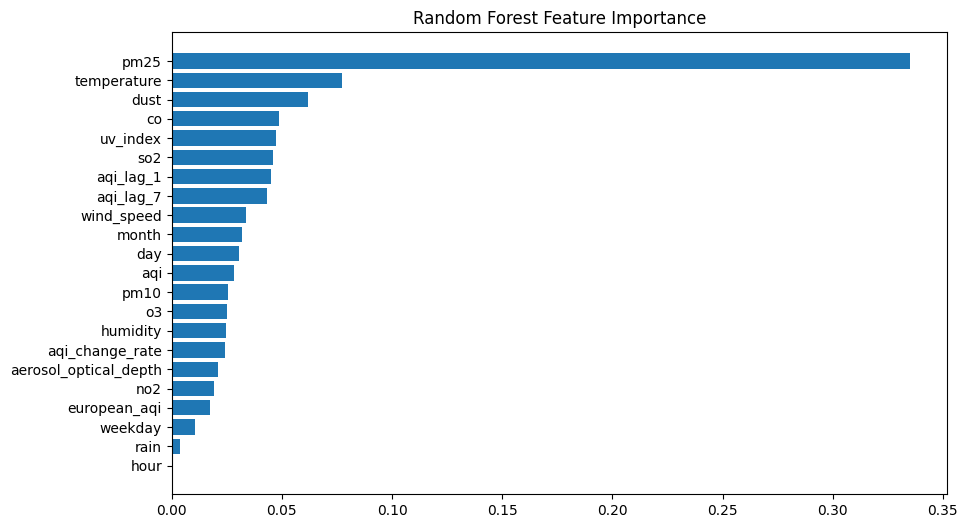

In [103]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.show()

In [104]:
importance.to_csv(
    "../outputs/random_forest_feature_importance.csv",
    index=False
)

***Model Register***

In [105]:
import hsml

mr = project.get_model_registry()

# Extract metrics from the best_r2 Series
rmse = best_r2['RMSE']
mae = best_r2['MAE']
r2 = best_r2['R2']

aqi_model = mr.sklearn.create_model(
    name="aqi_random_forest",
    description="AQI prediction model trained using Hopsworks Feature View",
    metrics={
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }
)

aqi_model.save(
    "karachi_aqi_model.pkl"
)

  0%|          | 0/6 [00:00<?, ?it/s]

Moving model files from 'karachi_aqi_model.pkl' to the model registry... This is the default behavior. Set keep_original_files=True to copy files instead.


Uploading /content/karachi_aqi_model.pkl: 0.000%|          | 0/18657761 elapsed<00:00 remaining<?

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/42159/models/aqi_random_forest/2


Model(name: 'aqi_random_forest', version: 2)

***SHAP***

In [106]:
!pip install shap

In [107]:
import shap
explainer = shap.TreeExplainer(
    best_rf
)

shap_values = explainer.shap_values(
    X_test
)

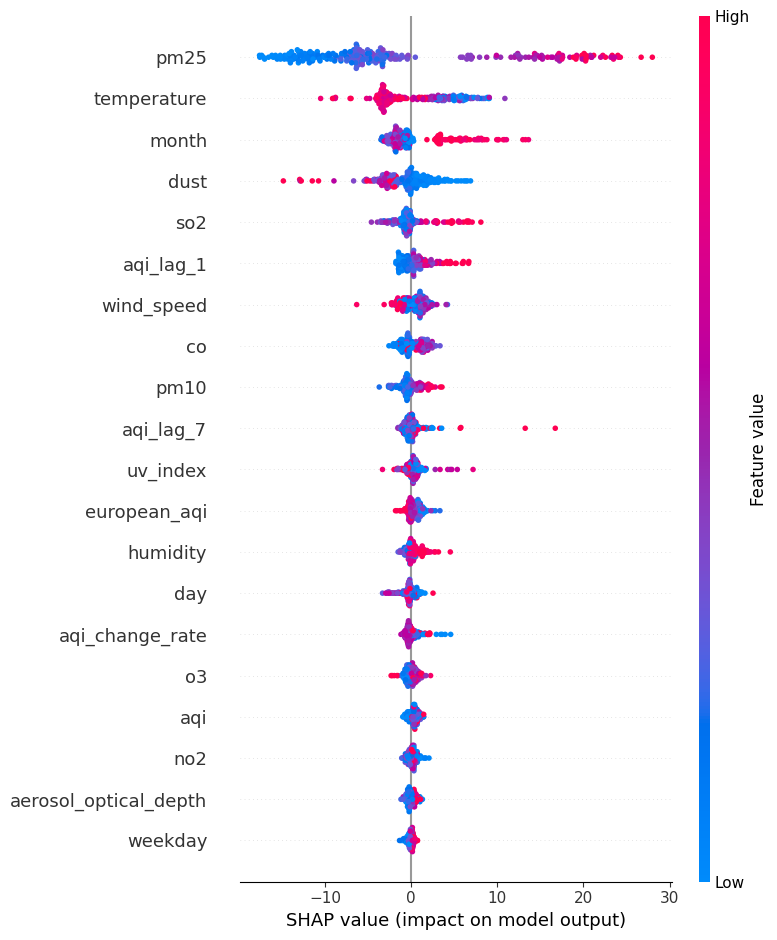

In [108]:
shap.summary_plot(
    shap_values,
    X_test
)

In [109]:
print(X_train.columns.tolist())

['pm10', 'pm25', 'co', 'no2', 'so2', 'o3', 'aerosol_optical_depth', 'dust', 'uv_index', 'aqi', 'european_aqi', 'hour', 'day', 'month', 'weekday', 'aqi_change_rate', 'aqi_lag_1', 'aqi_lag_7', 'temperature', 'humidity', 'wind_speed', 'rain']


In [110]:
import os
import matplotlib.pyplot as plt
import shap

# Create outputs folder in project root
os.makedirs("../outputs", exist_ok=True)

# Generate and save SHAP summary plot
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../outputs/shap_summary.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close()

print("SHAP summary plot saved successfully.")

SHAP summary plot saved successfully.


In [111]:
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

shap_importance.to_csv(
    "../outputs/shap_feature_importance.csv",
    index=False
)

shap_importance.head(10)

,Feature,Mean_Absolute_SHAP
1,pm25,10.424719
18,temperature,3.746389
13,month,2.578662
7,dust,2.177128
4,so2,1.283512
16,aqi_lag_1,1.173440
20,wind_speed,1.100972
2,co,1.064093
0,pm10,0.820099
17,aqi_lag_7,0.640080
